# 02 - Análise exploratória e seleção de variáveis

A EDA examina primeiro a Gold completa e só depois constrói o recorte usado na
modelagem. A ordem importa: **nenhuma coluna é descartada antes de a exclusão
estar justificada por uma medição.**

**Unidade de análise:** município-ano da rede municipal. Como não há microdados
por aluno, `alvo_alfabetizado` é uma **proxy municipal**: 1 quando a taxa
observada atingiu a meta municipal de 2025, 0 caso contrário.

In [1]:
# ==== 1. PREPARAÇÃO ====
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from src.preprocessing import ler_particionado
from src.preprocessing.config import LAKE_DIR
from src.preprocessing.build_features import salvar_dataset_modelagem
from src.modeling import resumir_alvo
from src.visualization import NEGATIVO, POSITIVO, SERIE, aplicar_estilo, limpar, salvar

aplicar_estilo()
IMAGENS = ROOT / "images"
pd.set_option("display.max_columns", 30)

gold = ler_particionado(LAKE_DIR / "gold" / "alfabetizacao_por_municipio")
indicador = ler_particionado(LAKE_DIR / "silver" / "pass" / "indicador_municipio")
print(f"Gold principal: {gold.shape[0]:,} linhas x {gold.shape[1]} colunas")
gold.info()

Gold principal: 10,896 linhas x 13 colunas
<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_municipio         10896 non-null  string 
 1   serie                10896 non-null  Int64  
 2   rede                 10896 non-null  str    
 3   taxa_alfabetizacao   10896 non-null  float64
 4   media_portugues      10896 non-null  float64
 5   meta_2025            10654 non-null  float64
 6   meta_2030            10654 non-null  float64
 7   nivel_alfabetizacao  10584 non-null  string 
 8   gap_meta_2025        10654 non-null  float64
 9   status_meta_2025     10654 non-null  str    
 10  _gold_processed_at   10896 non-null  str    
 11  _ingestion_date      10896 non-null  str    
 12  ano                  10896 non-null  int64  
dtypes: Int64(1), float64(5), int64(1), str(4), string(2)
memory usage: 1.8 MB


## Etapa 2 - Distribuição do indicador e da proxy

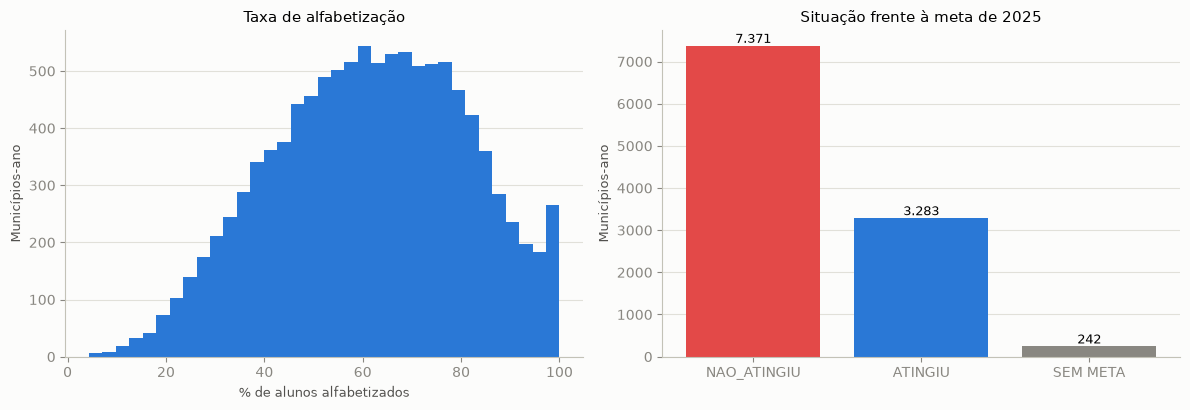

,count,mean,std,min,25%,50%,75%,max
ano,,,,,,,,
2023,5448.0,60.28,19.82,4.35,46.50,60.72,75.00,100.0
2024,5448.0,62.80,19.34,4.40,48.28,64.05,77.59,100.0


In [2]:
# ==== 2. DISTRIBUIÇÃO DO INDICADOR E SITUAÇÃO FRENTE À META ====
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))
eixos[0].hist(gold["taxa_alfabetizacao"].dropna(), bins=35, color=SERIE[0])
eixos[0].set(title="Taxa de alfabetização", xlabel="% de alunos alfabetizados",
             ylabel="Municípios-ano")

status = gold["status_meta_2025"].fillna("SEM META").value_counts()
cores = {"NAO_ATINGIU": NEGATIVO, "ATINGIU": POSITIVO, "SEM META": "#898781"}
eixos[1].bar(status.index, status.values, color=[cores[s] for s in status.index])
for i, valor in enumerate(status.values):
    eixos[1].annotate(f"{valor:,}".replace(",", "."), (i, valor),
                      ha="center", va="bottom", fontsize=9)
eixos[1].set(title="Situação frente à meta de 2025", ylabel="Municípios-ano")
for eixo in eixos:
    limpar(eixo)
plt.tight_layout()
salvar(fig, "02_distribuicao_indicador_proxy", IMAGENS)
plt.show()

display(gold.groupby("ano")["taxa_alfabetizacao"].describe().round(2))

**Leitura.** A taxa ocupa praticamente toda a escala de 0% a 100%, com média subindo
de 2023 para 2024. A maior parte das observações município-ano **não** atingiu a meta,
e **242 registros não têm meta municipal publicada** — eles não recebem rótulo e ficam
fora da modelagem, em vez de serem rotulados por omissão.

## Etapa 3 - Diagnóstico de data leakage

O alvo é `taxa_alfabetizacao >= meta_2025`. Qualquer coluna que reconstrua um dos
dois lados dessa desigualdade contamina o modelo. Aqui medimos o quanto cada
candidata reconstrói, em vez de decidir por intuição.

In [3]:
# ==== 3. QUANTO CADA CANDIDATA RECONSTRÓI O ALVO ====
municipal = indicador[indicador["rede"] == "3"].copy()
municipal["soma_niveis_5_8"] = municipal[
    [f"proporcao_aluno_nivel_{i}" for i in range(5, 9)]
].sum(axis=1)
print("Correlacao com a taxa de alfabetizacao:")
display(municipal[["taxa_alfabetizacao", "media_portugues", "soma_niveis_5_8"]]
        .corr().round(3))

rotulado = gold.dropna(subset=["status_meta_2025"]).copy()
rotulado["alvo"] = (rotulado["status_meta_2025"] == "ATINGIU").astype(int)
print("\nCorrelacao da taxa com o proprio alvo:",
      round(rotulado[["taxa_alfabetizacao", "alvo"]].corr().iloc[0, 1], 3))
print("Correlacao de media_portugues com a taxa, por ciclo:")
for ano in (2023, 2024):
    fatia = rotulado[rotulado["ano"] == ano]
    print(f"  {ano}: {fatia[['media_portugues', 'taxa_alfabetizacao']].corr().iloc[0, 1]:.4f}")

Correlacao com a taxa de alfabetizacao:


,taxa_alfabetizacao,media_portugues,soma_niveis_5_8
taxa_alfabetizacao,1.000,0.927,0.364
media_portugues,0.927,1.000,0.331
soma_niveis_5_8,0.364,0.331,1.000



Correlacao da taxa com o proprio alvo: 0.648
Correlacao de media_portugues com a taxa, por ciclo:
  2023: 0.9308
  2024: 0.9230


In [4]:
# ==== 4. VAZAMENTO RESIDUAL: A REGRA QUE DISPENSA O MODELO ====
# media_portugues nao e a taxa, mas e um proxy de 0,93 dela. Junto com meta_2025 -
# que e literalmente um dos lados da desigualdade - as duas quase reconstroem o
# rotulo. Ajustamos taxa ~ f(media_portugues) em 2023 e aplicamos a regra
# "taxa estimada >= meta" nos dois ciclos, sem treinar classificador nenhum.
base = rotulado.dropna(subset=["media_portugues", "meta_2025"])
treino_regra = base[base["ano"] == 2023]
ajuste = np.polyfit(treino_regra["media_portugues"], treino_regra["taxa_alfabetizacao"], 3)

for ano in (2023, 2024):
    fatia = base[base["ano"] == ano]
    estimada = np.polyval(ajuste, fatia["media_portugues"])
    regra = (estimada >= fatia["meta_2025"]).astype(int)
    print(f"{ano}: acuracia da regra deterministica = "
          f"{accuracy_score(fatia['alvo'], regra):.4f} "
          f"(prevalencia real {fatia['alvo'].mean():.3f})")

2023: acuracia da regra deterministica = 0.8406 (prevalencia real 0.181)
2024: acuracia da regra deterministica = 0.8709 (prevalencia real 0.434)


**Leitura - o limite do que se pode chamar de previsão.** As proporções por nível
SAEB somam correlação **0,986** com a taxa e são a mesma medição decomposta: saem.
`taxa_alfabetizacao`, `gap`, `status` e `nivel` são o alvo ou funções dele: saem.

Sobra um vazamento **residual e assumido**. `media_portugues` correlaciona **0,93**
com a taxa nos dois ciclos, e `meta_2025` é um dos lados da desigualdade que define
o rótulo. Uma regra sem nenhum classificador — ajustar a taxa a partir da nota e
comparar com a meta — acerta **84,1% em 2023 e 87,1% em 2024**, acima da acurácia do
modelo completo (71,7%).

Isso não invalida o trabalho, mas fixa a interpretação correta: o exercício é uma
**classificação contemporânea (nowcast)** do resultado de um ciclo já avaliado, não
uma previsão *ex ante*. Manter `media_portugues` é a escolha do projeto de
referência e é defensável — a nota é uma medida psicométrica distinta da taxa —, mas
a distância de 0,93 é pequena demais para chamar o resultado de antecipação.

### Variáveis mantidas

| Papel | Colunas |
|---|---|
| Numéricas | `media_portugues`, `meta_2025`, `meta_uf_2025`, `taxa_media_uf_loo` |
| Categóricas | `sigla_uf`, `regiao` |
| Identificação | `id_municipio`, `ano` (não entram em `X`) |
| Alvo | `alvo_alfabetizado` |

`taxa_media_uf_loo` é a média dos **outros** municípios da mesma UF e ano — o
próprio município é removido do cálculo, para não reintroduzir a sua taxa.

In [5]:
# ==== 5. MATERIALIZAÇÃO DO DATASET DE MODELAGEM ====
df = salvar_dataset_modelagem()
print(f"Dataset final: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head())
display(resumir_alvo(df))
display(df.isna().sum().to_frame("nulos"))

Dataset final: 10,654 linhas x 9 colunas


,id_municipio,ano,sigla_uf,regiao,media_portugues,meta_2025,meta_uf_2025,taxa_media_uf_loo,alvo_alfabetizado
0,1100031,2023,RO,Norte,767.88,72.53,69.5,65.00,0
1,1100072,2023,RO,Norte,747.89,65.31,69.5,65.21,0
2,1101609,2023,RO,Norte,745.68,60.25,69.5,65.36,0
3,1101807,2023,RO,Norte,752.37,63.63,69.5,65.26,0
4,1302900,2023,AM,Norte,731.07,61.93,61.3,46.13,0


,ano,registros,proporcao_atingiu_meta
0,2023,5302,0.181
1,2024,5352,0.434


,nulos
id_municipio,0
ano,0
sigla_uf,0
regiao,0
media_portugues,0
meta_2025,0
meta_uf_2025,0
taxa_media_uf_loo,0
alvo_alfabetizado,0


**Leitura.** 10.654 registros e 9 colunas. A prevalência do alvo salta de **18,1%
em 2023 para 43,4% em 2024** — 25,3 pontos. Esse deslocamento é a maior ameaça à
generalização temporal e reaparece como limitação em todo o projeto. As ausências
são poucas e ficam a cargo do imputador, dentro do `Pipeline`.

## Etapa 4 - Padrões territoriais e correlações

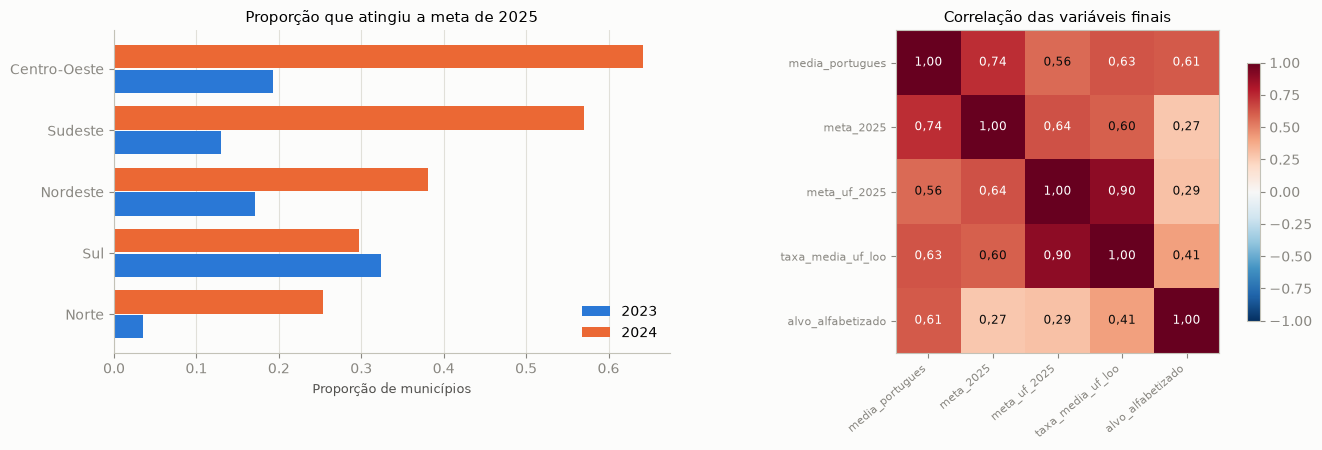

ano,2023,2024
regiao,,
Centro-Oeste,19.3,64.2
Nordeste,17.1,38.2
Norte,3.5,25.4
Sudeste,13.0,57.1
Sul,32.4,29.7


In [6]:
# ==== 6. TERRITÓRIO E CORRELAÇÕES DAS VARIÁVEIS FINAIS ====
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.6))
regional = (df.groupby(["regiao", "ano"])["alvo_alfabetizado"].mean()
            .unstack("ano").sort_values(2024))
posicao = np.arange(len(regional))
eixos[0].barh(posicao - 0.2, regional[2023], 0.38, label="2023", color=SERIE[0])
eixos[0].barh(posicao + 0.2, regional[2024], 0.38, label="2024", color=SERIE[1])
eixos[0].set(yticks=posicao, title="Proporção que atingiu a meta de 2025",
             xlabel="Proporção de municípios")
eixos[0].set_yticklabels(regional.index)
eixos[0].legend()
limpar(eixos[0], grade="x")

colunas = ["media_portugues", "meta_2025", "meta_uf_2025",
           "taxa_media_uf_loo", "alvo_alfabetizado"]
matriz = df[colunas].corr()
imagem = eixos[1].imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
for (i, j), valor in np.ndenumerate(matriz.to_numpy()):
    eixos[1].text(j, i, f"{valor:.2f}".replace(".", ","), ha="center", va="center",
                  fontsize=8.5, color="white" if abs(valor) > 0.6 else "#0b0b0b")
eixos[1].set(xticks=range(len(colunas)), yticks=range(len(colunas)),
             title="Correlação das variáveis finais")
eixos[1].set_xticklabels(colunas, rotation=40, ha="right", fontsize=8)
eixos[1].set_yticklabels(colunas, fontsize=8)
eixos[1].grid(False)
fig.colorbar(imagem, ax=eixos[1], shrink=0.8)
plt.tight_layout()
salvar(fig, "02_padroes_territoriais_correlacoes", IMAGENS)
plt.show()

display((df.groupby(["regiao", "ano"])["alvo_alfabetizado"].mean()
         .unstack("ano") * 100).round(1))

**Leitura.** Duas coisas decidem a modelagem.

**A melhora não foi homogênea.** Todas as regiões avançam entre os ciclos, exceto o
**Sul**, que recua de 32,4% para 29,7% — a única a piorar, enquanto Centro-Oeste
(19,3% → 64,2%) e Sudeste (13,0% → 57,1%) mais que triplicam. Um modelo ajustado no
padrão regional de 2023 herda uma geografia que 2024 já não tem.

**Há redundância territorial.** `media_portugues` tem a maior correlação com o alvo
(**0,61**), mas `meta_uf_2025` e `taxa_media_uf_loo` correlacionam **0,90** entre si:
carregam quase a mesma informação estadual. Isso justifica manter regularização L2 no
modelo e antecipa por que os coeficientes de UF devem ser lidos com cautela.

## Etapa 5 - Hipóteses para a modelagem

| # | Hipótese | Como será verificada |
|---|---|---|
| H1 | Maior proficiência em Português está associada a maior chance de atingir a meta | coeficiente, permutation importance e SHAP no notebook 03 |
| H2 | O contexto estadual captura desigualdades territoriais relevantes | coeficientes das dummies de UF e sua importância medida |
| H3 | O salto de prevalência entre 2023 e 2024 reduz a generalização temporal | comparação entre validação cruzada em 2023 e holdout de 2024 |
| H4 | As associações não devem ser lidas como efeitos causais | permanece como restrição de interpretação, não é testável nesta base |

As hipóteses são conferidas no notebook 03 e o veredito de cada uma está no
relatório técnico.